<a href="https://colab.research.google.com/github/parulgoell/ai-attendance-agent/blob/main/Water_Supply_Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

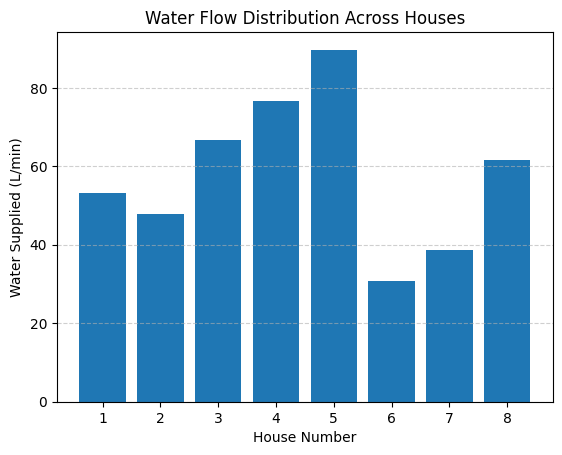

In [1]:
# -------------------------------------------------------
# Water Supply Optimizer : Constraint-Based Distribution
# -------------------------------------------------------

import numpy as np                  # For mathematical calculations
import matplotlib.pyplot as plt     # For generating water flow charts

# -----------------------------
# 1. Setup Network Parameters
# -----------------------------

np.random.seed(0)                    # Fix randomness for reproducibility

num_houses = 8                       # Total number of houses supplied by the tank
total_water_available = 500          # Total water available in liters per minute

# Random demand per house (in liters per minute)
demand = np.random.randint(30, 100, num_houses)

# Minimum pressure required for each house (arbitrary units)
min_pressure = np.random.uniform(0.6, 1.0, num_houses)

# Create an array to store actual water supplied after optimization
supply = np.zeros(num_houses)

# -----------------------------
# 2. Constraint Satisfaction Logic
# -----------------------------

remaining_water = total_water_available   # Track remaining water after each allocation

# Compute priority for each house based on pressure constraints
priority = demand * min_pressure          # Higher demand + higher pressure = higher priority

# Get the order in which houses should be allocated water
allocation_order = np.argsort(-priority)  # Sort descending by priority

# Assign water using simple greedy constraint logic
for house in allocation_order:                # For each house by priority
    required = demand[house]                  # Water the house ideally wants
    pressure_factor = min_pressure[house]     # Pressure requirement scale

    # Allocate water proportional to pressure requirement but not exceeding demand
    alloc = min(required * pressure_factor, remaining_water)

    supply[house] = alloc                     # Store allocated water
    remaining_water -= alloc                  # Reduce available tank supply

# -----------------------------
# 3. Normalize if Over-Allocated
# -----------------------------

total_allocated = supply.sum()                # Total water assigned

if total_allocated > total_water_available:   # Safety check for over-allocation
    supply = supply * (total_water_available / total_allocated)

# -----------------------------
# 4. Output: Water Flow Distribution Chart
# -----------------------------

houses = np.arange(1, num_houses + 1)         # House numbers for x-axis labels

plt.bar(houses, supply)                       # Bar chart of supplied water
plt.xlabel("House Number")                    # Label for x-axis
plt.ylabel("Water Supplied (L/min)")          # Label for y-axis
plt.title("Water Flow Distribution Across Houses")  # Figure title
plt.grid(axis="y", linestyle="--", alpha=0.6) # Slight visual grid for clarity
plt.show()                                    # Display the chart
